In [2]:
import numpy as np
import pandas as pd
# import math

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import h5py
import json
import matplotlib 
from matplotlib.patches import Rectangle
from mpl_toolkits.axes_grid1 import make_axes_locatable
from scipy.signal import hilbert, savgol_filter
from scipy.optimize import curve_fit


import os
import sys  
import warnings

from ast import literal_eval

from qutip import  *

sys.path.append('../../scripts') 

from qutip_tools import *

In [3]:
# define basic figure sizes
bwidth=7    
bheight=5
base_font = 20

matplotlib.rcParams.update({'font.size': base_font,"legend.fontsize":base_font-4 ,"font.family": "serif", 
                            "font.serif": "CMU Serif, Times New Roman",
                           'text.usetex' : True })

sns.set_palette("colorblind")

fig_route = "../../plots/synthetize/"

ll=100
J=1
a = 1 # lattice spacing
data_route = "../../data/exact_diag_new/L={}/".format(ll)




# Functions

In [4]:
def get_instant_freq(y,time_range):

    
    # Compute analytic signal via Hilbert transform (no padding)
    analytic_signal = hilbert(y)
    phase = np.unwrap(np.angle(analytic_signal))
 
    # Compute instantaneous frequency
    dt = np.mean(np.diff(time_range))
    ints_freq = np.gradient(phase, dt)  # rad / (time unit)
    
    # Apply smoothing filter with edge handling
    smooth_freq = savgol_filter(ints_freq, 21, 3, mode='nearest')
        
    return ints_freq, smooth_freq

# Read data and create dataframe

In [5]:
file_list = get_file_names_on([], data_route)


In [6]:
# read the parameter dictionary to initialize 
param_dict, times, occupations, d0_density, qubit_rho, entropy = load_exact_diag(data_route, file_list[0])  

data_dict =  {key: [] for key in param_dict}
data_dict["times"] = []
data_dict["occupations"] = []
data_dict["d0_density"] = []
data_dict["qubit_rho"] = []
data_dict["entropy"] = []
data_dict["time_at_bond"] = []
data_dict["Max_entropy"] = []
data_dict["cos_theta"] = []
data_dict["sin_phi"] = []
data_dict["bloch_radius"] = []
data_dict["backaction_time"] = []
data_dict["backaction_max"] = []
data_dict["Delta_phi"] = []
data_dict["Delta_phi_max"] = []
data_dict["bloch_radius_last"] = []
data_dict["purity"] = []
data_dict["purity_last"] = []
data_dict["transmission"] = []
data_dict["max_transmission"] = []
data_dict["free_freq_hilbert"] = []
data_dict["free_freq_hilbert_last"] = []
data_dict["free_freq_deriv"] = []
data_dict["free_freq_deriv_last"] = []
data_dict["couple_freq_hilbert"] = []
data_dict["couple_freq_deriv"] = []
data_dict["couple_freq_hilbert_last"] = []
data_dict["couple_freq_deriv_last"] = []
data_dict["hilbert_time_range"] = [] # different length due to edge artifacts

problem_cases = []

for i in range(0,len(file_list)):
    file_name = file_list[i]
    param_dict, times, occupations, d0_density, qubit_rho, entropy = load_exact_diag(data_route, file_name) 
    # initialize the meta data
    for key in param_dict.keys():
        data_dict[key].append(param_dict[key])

    #  estimate the time that wavepacket spends at bondf
    bond_density = occupations[param_dict["bond_index"], :] + occupations[param_dict["bond_index"]+1, :]
    tau_bond = get_time_at_bond(times, bond_density)
    
    # get the bloch angles fo the qubit
    costheta_list, sinphi_list = get_bloch_angles_time(qubit_rho)

    # get the backaction
    rho_free_list, theta_free_list, phi_free_list = get_free_orbit(qubit_rho[0], costheta_list[0], param_dict["phi"],
                                                                   times,param_dict["t"])
    backaction = get_euclidean_distance(costheta_list, sinphi_list, theta_free_list, phi_free_list)
    
    purity_t = get_purity(qubit_rho)
    bloch_radius = np.sqrt(2*purity_t[1:]-1).real

    # approximate delta phi via the chord (backaction variable) between the orbits
    # catch the exception when the bloch radius is basically zero
    try:
        with warnings.catch_warnings():
            warnings.filterwarnings("error",category=RuntimeWarning)
            # use the law of cosines to get Delta phi where one side has length 1 (pure case)
            cos_ϕ = (1 + bloch_radius**2 - backaction**2) / (2*bloch_radius)
            Δϕ = np.arccos(np.clip(cos_ϕ, -1.0, 1.0))
            # Δϕ = 2*np.arcsin(backaction.real/(2*bloch_radius.real))
     
    except RuntimeWarning as e:
        problem_cases.append(param_dict)
        #parg = backaction.real/(2*bloch_radius.real)
        parg = backaction.real/(2)
        parg[parg > 1] = 1
        Δϕ = 2*np.arcsin(parg)

    coupled_osc = np.asarray(np.real(costheta_list))
    coupled_theta = np.arccos(coupled_osc)

    rabi_osc = np.cos(theta_free_list)

    # now approximate the change in rabi frequency to prove zeno we use two methods
    # derivative of theta to get frequency for low freq
    dt = times[1] - times[0]
    theta_free_deriv = np.abs(np.gradient(theta_free_list, dt))
    coupled_theta_deriv = np.abs(np.gradient(coupled_theta, dt))

    # use hilbert for high freq
    _, rabi_om = get_instant_freq(rabi_osc - np.mean(rabi_osc),times)
    _, couple_om = get_instant_freq(coupled_osc - np.mean(coupled_osc),times)

    # remove the artifacts from edge effects
    rems = int(0.12*len(rabi_om))
    rabi_om = rabi_om[rems:-rems]
    couple_om = couple_om[rems:-rems]

    # occupation to the right of the bond at
    occu_T = np.sum(occupations[param_dict["bond_index"]+2:, :], axis=0)

    # save raw data 
    data_dict["times"].append(list(times))
    data_dict["occupations"].append(occupations)
    data_dict["d0_density"].append(d0_density) 
    data_dict["qubit_rho"].append(qubit_rho)
    # normalize entropy by maximally entangled singled 
    data_dict["entropy"].append(list((entropy/np.log(2))))
    # save processed data
    data_dict["time_at_bond"].append(tau_bond)
    data_dict["Max_entropy"].append(max(entropy/np.log(2)))
    data_dict["cos_theta"].append(costheta_list)
    data_dict["sin_phi"].append(sinphi_list)
    data_dict["backaction_time"].append(backaction)
    data_dict["bloch_radius"].append(bloch_radius.real)
    data_dict["Delta_phi"].append(Δϕ)
    data_dict["backaction_max"].append(max(backaction))
    data_dict["Delta_phi_max"].append(max(Δϕ))
    data_dict["bloch_radius_last"].append(bloch_radius.real[-1])
    data_dict["purity_last"].append(purity_t.real[-1])
    data_dict["purity"].append(purity_t)
    data_dict["transmission"].append(occu_T)
    data_dict["max_transmission"].append(max(occu_T))
    data_dict["free_freq_hilbert"].append(rabi_om)
    data_dict["free_freq_hilbert_last"].append(rabi_om[-1])
    data_dict["free_freq_deriv"].append(theta_free_deriv)
    data_dict["free_freq_deriv_last"].append(theta_free_deriv[-1])
    data_dict["couple_freq_hilbert"].append(couple_om)
    data_dict["couple_freq_hilbert_last"].append(couple_om[-1])
    data_dict["couple_freq_deriv"].append(coupled_theta_deriv)
    data_dict["couple_freq_deriv_last"].append(coupled_theta_deriv[-1])
    data_dict["hilbert_time_range"].append(times[rems:-rems])

full_data_df = pd.DataFrame.from_dict(data_dict)


not possible to estimate time at bond for 
not possible to estimate time at bond for 
not possible to estimate time at bond for 
not possible to estimate time at bond for 
not possible to estimate time at bond for 
not possible to estimate time at bond for 
not possible to estimate time at bond for 
not possible to estimate time at bond for 
not possible to estimate time at bond for 
not possible to estimate time at bond for 
not possible to estimate time at bond for 
not possible to estimate time at bond for 
not possible to estimate time at bond for 
not possible to estimate time at bond for 
not possible to estimate time at bond for 
not possible to estimate time at bond for 
not possible to estimate time at bond for 
not possible to estimate time at bond for 
not possible to estimate time at bond for 
not possible to estimate time at bond for 
not possible to estimate time at bond for 
not possible to estimate time at bond for 
not possible to estimate time at bond for 
not possibl

In [7]:
"""##### THIS IS NECESSARY ONLY BECAUSE WE HAD SOME DUPLCIATES BECAUSE OF MAX TIME
drop_d = ['L_qpc', 'Omega', 't', 'J', 'Jp', 'bond_index', 'K0', 'X0', 'Spread', 
          'qubit_init', 'Re_qubit_0', 'Im_qubit_0', 'Re_qubit_1', 'Im_qubit_1', 'phi', 'alfabond']
full_data_df = full_data_df.sort_values(by="maxt_time") .drop_duplicates(subset=drop_d, keep="last")"""

full_data_df.describe()

,L_qpc,Omega,t,J,Jp,bond_index,K0,X0,Spread,maxt_time,...,Max_entropy,backaction_max,Delta_phi_max,bloch_radius_last,purity_last,max_transmission,free_freq_hilbert_last,free_freq_deriv_last,couple_freq_hilbert_last,couple_freq_deriv_last
count,14547.0,14547.000000,14547.000000,14547.0,14547.0,14547.0,14547.000000,14547.0,14547.0,14547.0,...,1.454700e+04,14547.000000,14547.000000,14547.000000,14547.000000,14547.000000,14547.000000,14547.000000,14547.000000,1.454700e+04
mean,100.0,2.449526,0.511815,1.0,1.0,50.0,1.005130,30.0,7.0,300.0,...,4.151373e-01,0.667961,0.967036,0.787610,0.840753,0.625929,0.953269,0.779949,0.950320,5.384788e-01
std,0.0,3.081091,0.888107,0.0,0.0,0.0,0.479817,0.0,0.0,0.0,...,3.548743e-01,0.525907,0.967201,0.247344,0.160438,0.319705,1.342683,1.048249,1.349317,9.887108e-01
min,100.0,0.050000,0.000100,1.0,1.0,50.0,0.003185,30.0,7.0,300.0,...,5.786859e-09,0.000026,0.000026,0.000114,0.500000,0.000017,0.016318,0.000200,-0.632497,4.467437e-09
25%,100.0,0.300000,0.050000,1.0,1.0,50.0,0.628319,30.0,7.0,300.0,...,3.686073e-02,0.132677,0.133069,0.653595,0.713593,0.355432,0.158556,0.100000,0.156513,3.996383e-02
50%,100.0,1.000000,0.200000,1.0,1.0,50.0,1.178097,30.0,7.0,300.0,...,3.799878e-01,0.601399,0.636685,0.887300,0.893650,0.668091,0.458254,0.400000,0.403292,1.419186e-01
75%,100.0,3.000000,0.650000,1.0,1.0,50.0,1.413717,30.0,7.0,300.0,...,7.698899e-01,1.107914,1.515859,0.994431,0.994446,0.954540,1.354642,1.200000,1.358954,6.202027e-01
max,100.0,10.000000,5.000000,1.0,1.0,50.0,1.570796,30.0,7.0,300.0,...,1.000000e+00,1.999983,3.141593,1.000000,1.000000,0.999995,6.903294,6.734217,7.150354,6.734217e+00


# Global Params

In [8]:
Om_ = 0.05 
X0_ = 30
Δ = 7.0
LL = 100
Bindex = full_data_df["bond_index"].sort_values().unique()[0]
af = full_data_df["alfabond"].sort_values().unique()[2] # af is the qubit  occupation at the time of measurement 
prob0 = np.cos(af/2)**2

print(af)
print("Qubit occupation at measurement time:")
print(prob0)

# get some general arrays
K0_unique = full_data_df["K0"].sort_values().unique()
rabi_unique = full_data_df["t"].sort_values().unique()

cond_ = (full_data_df["Omega"]==Om_)  & (full_data_df["qubit_init"]=="fixed") & (full_data_df["X0"]==X0_) & (full_data_df["alfabond"]==af)

data_df = full_data_df[cond_].sort_values(by="K0")


0.7853981633974483
Qubit occupation at measurement time:
0.8535533905932737


# Scattering

Since we are doing reflectometry, we should compare to the scattering/current regimes that are mentioned in gurvitz ad Korotkov and most literature

In [9]:
def get_transmision_proba(gt, K0, Δ):
    # calculate the transmision coefficient for the QPC wavepacket
    # gt = the interaction strength
    # momentum for the integration
    k_arr = np.linspace(-100, 100, 5000)
    m = 1/(2*J**2) # effective mass for the quadratic dispersion

    Psi0k_abs = (Δ ** 2 / np.pi)**(1/2) * np.exp(-Δ**2*(k_arr - K0)** 2 )
    # now with the wave packet weights
    T_k = 1 / (1 + (m*gt / k_arr)** 2)
    T_tot = simpson(T_k * Psi0k_abs, dx=k_arr[1] - k_arr[0])

    return T_tot

## Looking at the general behaviour

as a fucntion of Interaction strength, k0 and rabi frequency

In [10]:
# gettinf the transmision proba from literature

print(full_data_df.columns)
# calculate the transmission probas for each Om_
omega_list = np.sort(full_data_df[full_data_df["Omega"]<2].Omega.unique() )
print(omega_list)
colorb_list = sns.color_palette("Blues", len(omega_list))

Tinit = 1 # unocupeid proba
transm_dict = {"Omega": [],"K0": [], "t": [], "Transmission": [], "slow_q_cond": [], "weak_meassurement_cond": [],"meassure_time" :[] ,"time_cond": [] }

for Om in omega_list:
    for K0 in K0_unique:
        for rabi in rabi_unique:
            V0 = Om*prob0
            Tprob = get_transmision_proba(V0, K0, Δ)
            currexp = Tinit+prob0*(Tprob-Tinit)
            slow_q_cond = 2*(J/(prob0*Om))**2*((Tinit-Tprob)**2)/Tinit
            weak_con = ((Tprob + Tinit)**2)/(2*Tprob - 2*Tinit)**2
            time_cond = J/(Tinit*Om*prob0)
            Spread_B = (Δ/np.sqrt(2))*np.sqrt(1 + ( (Bindex - X0_)/(Δ*Δ*K0))**2 )
            mess_time = Spread_B/(2*J*K0)
            
            transm_dict["Omega"].append(Om)
            transm_dict["K0"].append(K0)
            transm_dict["Transmission"].append(currexp)
            transm_dict["t"].append(rabi)
            transm_dict["slow_q_cond"].append(slow_q_cond)
            transm_dict["weak_meassurement_cond"].append(weak_con)
            transm_dict["meassure_time"].append(mess_time)
            transm_dict["time_cond"].append(time_cond)

transm_df = pd.DataFrame.from_dict(transm_dict)

Index(['L_qpc', 'Omega', 't', 'J', 'Jp', 'bond_index', 'K0', 'X0', 'Spread',
       'maxt_time', 'del_tau', 'qubit_init', 'Re_qubit_0', 'Im_qubit_0',
       'Re_qubit_1', 'Im_qubit_1', 'phi', 'alfabond', 'times', 'occupations',
       'd0_density', 'qubit_rho', 'entropy', 'time_at_bond', 'Max_entropy',
       'cos_theta', 'sin_phi', 'bloch_radius', 'backaction_time',
       'backaction_max', 'Delta_phi', 'Delta_phi_max', 'bloch_radius_last',
       'purity', 'purity_last', 'transmission', 'max_transmission',
       'free_freq_hilbert', 'free_freq_hilbert_last', 'free_freq_deriv',
       'free_freq_deriv_last', 'couple_freq_hilbert', 'couple_freq_deriv',
       'couple_freq_hilbert_last', 'couple_freq_deriv_last',
       'hilbert_time_range'],
      dtype='object')
[0.05 0.1  0.3  0.6  1.  ]


According to Romit et al. this we require K0_unique/Spread_B To be much bigger than 0.5*(Om_*prob0)**2 for us to have weak measurements. In addition according to korotkov these models should only work when the corrent/ transmission rate on the detector change very little. **THis is essentially the how long/strong is too much which is related to the purity of the qubit, we want to aboid learning too much to keep withhin weak measurements**

In [38]:
transm_df.t.unique()

array([1.0e-04, 5.0e-04, 1.0e-03, 5.0e-03, 1.0e-02, 2.0e-02, 3.0e-02,
       4.0e-02, 5.0e-02, 6.0e-02, 7.0e-02, 8.0e-02, 8.5e-02, 9.0e-02,
       9.5e-02, 1.0e-01, 1.5e-01, 2.0e-01, 2.5e-01, 3.0e-01, 3.5e-01,
       4.0e-01, 4.5e-01, 5.0e-01, 5.5e-01, 6.0e-01, 6.5e-01, 7.0e-01,
       7.5e-01, 8.0e-01, 8.5e-01, 9.0e-01, 9.5e-01, 1.0e+00, 2.5e+00,
       5.0e+00])

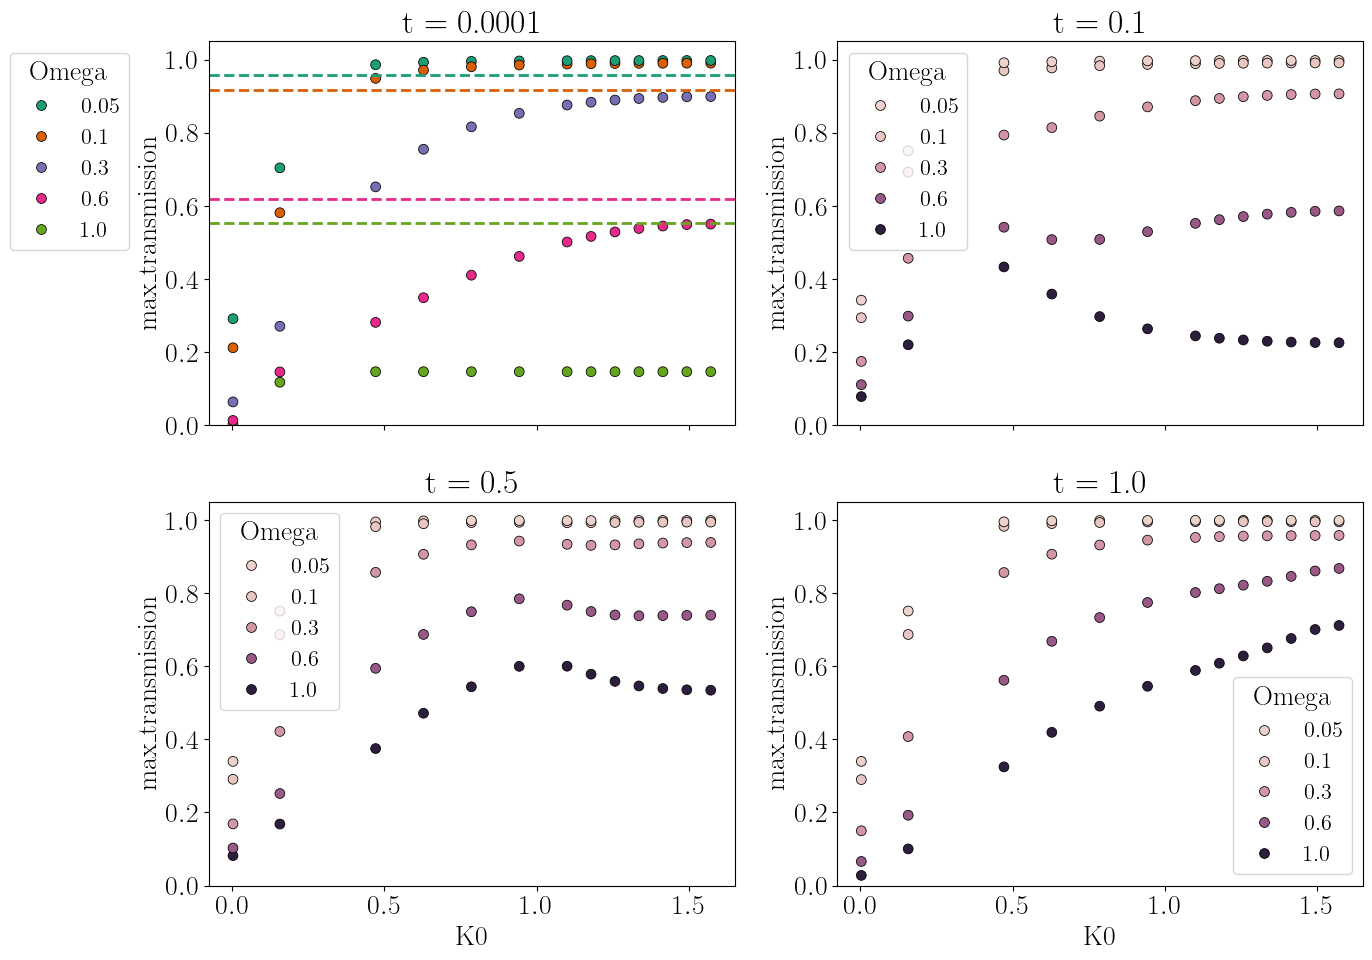

In [37]:
f,ax = plt.subplots(2,2, figsize=(2*bwidth, 2*bheight),sharex=True)

t_ = 0.0001
cond_ = (full_data_df["alfabond"]==af) & (full_data_df["t"]==t_) & (full_data_df["Omega"]<2)
sns.scatterplot(ax=ax[0,0], x="K0", y="max_transmission", hue="Omega",data=full_data_df[cond_], s=50, edgecolor="black", palette="Dark2")
# plot theory scattering
cond2_ = (transm_df["t"]==t_) & (transm_df["Omega"]<2)
# sns.scatterplot(ax=ax[0,0], x="K0", y="Transmission", hue="Omega", data=transm_df[cond2_], s=50, marker="x",linewidth=2)

# plot condition where hteory validity is expected
cond_cond_ = (transm_df["t"]==t_) & (transm_df["Omega"]<2)  & (transm_df["meassure_time"] >= transm_df["time_cond"])
res_df = transm_df[cond_cond_ ].sort_values('K0').groupby(['Omega', 't']).last()
n_colors = len(res_df)
colors = [plt.cm.Dark2(i / n_colors) for i in range(n_colors)]

#for i, (idx, row) in enumerate(res_df.iterrows()):
#    ax[0,0].axvline(row["K0"], color=colors[i], zorder=0, linewidth=3, linestyle="--")

ax[0,0].legend(bbox_to_anchor=(-0.4, 1), loc='upper left', title="Omega")
ax[0,0].set_title("t = {}".format(t_))
ax[0,0].set_ylim(0,1.05)

t_ = 0.1
cond_ = (full_data_df["alfabond"]==af) & (full_data_df["t"]==t_) & (full_data_df["Omega"]<2)
sns.scatterplot(ax=ax[0,1], x="K0", y="max_transmission", hue="Omega", data=full_data_df[cond_], s=50, edgecolor="black")
ax[0,1].set_title("t = {}".format(t_))
ax[0,1].set_ylim(0,1.05)

t_ = 0.5
cond_ = (full_data_df["alfabond"]==af) & (full_data_df["t"]==t_) & (full_data_df["Omega"]<2)
sns.scatterplot(ax=ax[1,0], x="K0", y="max_transmission", hue="Omega", data=full_data_df[cond_],  s=50, edgecolor="black")
ax[1,0].set_title("t = {}".format(t_))
ax[1,0].set_ylim(0,1.05)

t_ = 1.0
cond_ = (full_data_df["alfabond"]==af) & (full_data_df["t"]==t_) & (full_data_df["Omega"]<2)
sns.scatterplot(ax=ax[1,1], x="K0", y="max_transmission", hue="Omega", data=full_data_df[cond_],  s=50, edgecolor="black")
ax[1,1].set_title("t = {}".format(t_))
ax[1,1].set_ylim(0,1.05)


Om_interest = [0.05, 0.1, 0.5, 0.6]
for i in range(0,len(Om_interest)):
    ax[0,0].axhline((J- 0.5*prob0*Om_interest[i])**2, color='black', linestyle='--', linewidth=2, c=colors[i])
plt.tight_layout()


plt.savefig(fig_route+"transmission_vs_K0.png", bbox_inches="tight")

In [65]:
Om = 0.05
cond_ = (full_data_df["alfabond"]==af) & (full_data_df["Omega"]== Om )
om01_df = full_data_df[cond_].pivot(index='K0', columns='t', values='max_transmission')
om01_df.index = [f"{y:.3g}" for y in om01_df.index]


Om = 0.1
cond_ = (full_data_df["alfabond"]==af) & (full_data_df["Omega"]== Om )
om03_df = full_data_df[cond_].pivot(index='K0', columns='t', values='max_transmission')
om03_df.index = [f"{y:.3g}" for y in om03_df.index]

Om = 0.3
cond_ = (full_data_df["alfabond"]==af) & (full_data_df["Omega"]== Om )
om06_df = full_data_df[cond_].pivot(index='K0', columns='t', values='max_transmission')
om06_df.index = [f"{y:.3g}" for y in om06_df.index]

Om = 0.6
cond_ = (full_data_df["alfabond"]==af) & (full_data_df["Omega"]== Om )
om1_df = full_data_df[cond_].pivot(index='K0', columns='t', values='max_transmission')
om1_df.index = [f"{y:.3g}" for y in om1_df.index]


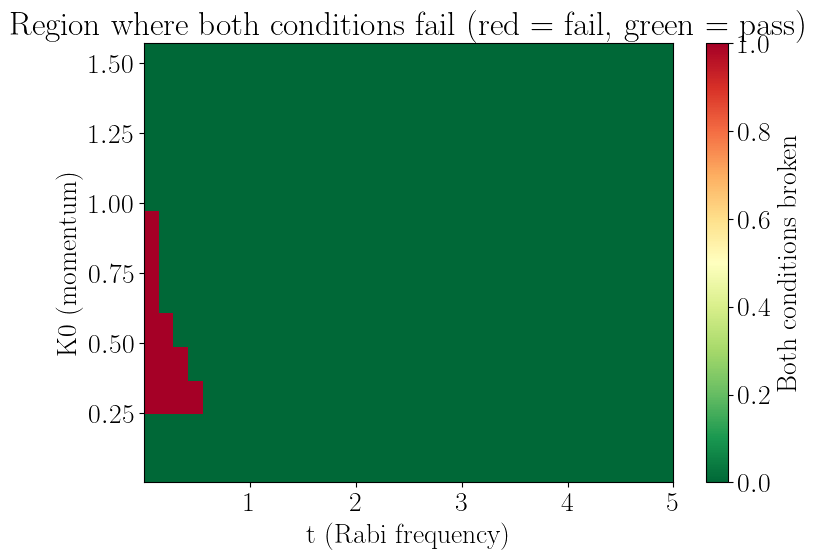

In [66]:
# Create a grid of K0 and t values
k0_vals = np.sort(transm_df['K0'].unique())
t_vals = np.sort(transm_df['t'].unique())

# Create a 2D mask showing where BOTH conditions are broken (region where theory fails)
condition_grid = np.zeros((len(k0_vals), len(t_vals)))

for i, k0 in enumerate(k0_vals):
    for j, t in enumerate(t_vals):
        row = transm_df[(transm_df['K0'] == k0) & (transm_df['t'] == t) & (transm_df["Omega"]==0.05)]
        if not row.empty:
            # Both conditions must be broken: meassure_time too short AND t too small
            cond = (row['meassure_time'] < row['time_cond']).iloc[0] & (row['t'] < row['slow_q_cond']).iloc[0]
            condition_grid[i, j] = 1 if cond else 0

# Visualize with proper orientation: large K0 at top, small t at left
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(condition_grid, origin='lower', aspect='auto', 
               extent=[t_vals.min(), t_vals.max(), k0_vals.min(), k0_vals.max()],
               cmap='RdYlGn_r')
ax.set_xlabel('t (Rabi frequency)')
ax.set_ylabel('K0 (momentum)')
ax.set_title('Region where both conditions fail (red = fail, green = pass)')
plt.colorbar(im, ax=ax, label='Both conditions broken')
plt.tight_layout()

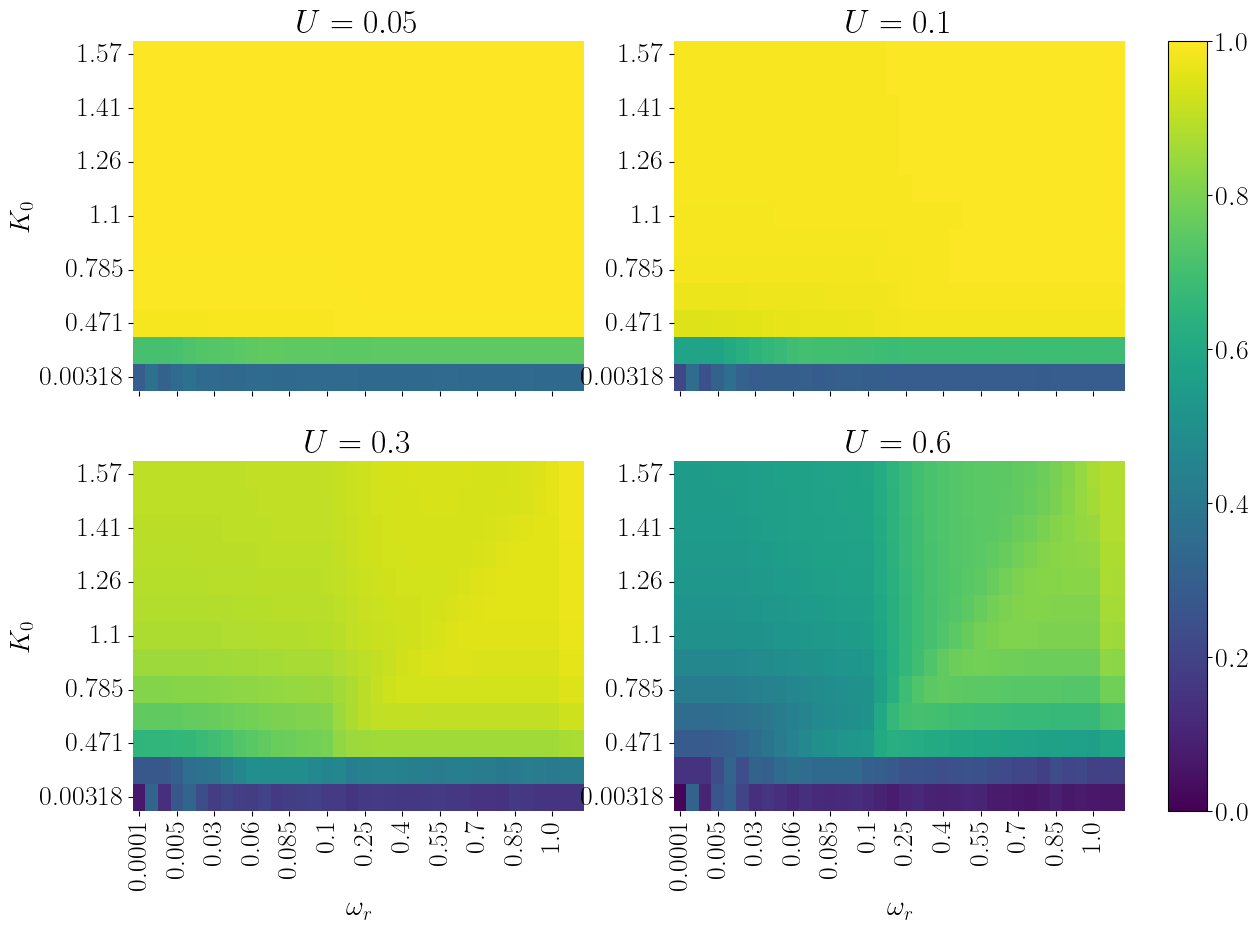

In [67]:
f,ax = plt.subplots(2,2, figsize=(2*bwidth, 2*bheight), sharex=True)
hm = sns.heatmap(om01_df, annot=False, fmt=".2f", cmap="viridis", ax=ax[0,0], vmin=0, vmax=1, cbar=False)
sns.heatmap(om03_df, annot=False, fmt=".2f", cmap="viridis", ax=ax[0,1], vmin=0, vmax=1, cbar=False)
sns.heatmap(om06_df, annot=False, fmt=".2f", cmap="viridis", ax=ax[1,0], vmin=0, vmax=1, cbar=False)
sns.heatmap(om1_df, annot=False, fmt=".2f", cmap="viridis", ax=ax[1,1], vmin=0, vmax=1, cbar=False)


ax[0,0].invert_yaxis()
ax[0,1].invert_yaxis()
ax[1,0].invert_yaxis()
ax[1,1].invert_yaxis()

ax[0,0].set_title(r"$U = 0.05$")
ax[0,1].set_title(r"$U = 0.1$")
ax[1,0].set_title(r"$U = 0.3$")
ax[1,1].set_title(r"$U = 0.6$")
ax[0,0].set_ylabel("$K_0$")
ax[1,0].set_ylabel("$K_0$")
ax[0,0].set_xlabel("")
ax[0,1].set_xlabel("")
ax[1,0].set_xlabel(r"$\omega_r$")
ax[1,1].set_xlabel(r"$\omega_r$")

f.colorbar(hm.collections[0], ax=ax.ravel().tolist(), fraction=0.046, pad=0.04)

#plt.tight_layout()

# Single example

The rate equation part for the change in current is taken from Eqs.(2.5), (3.2) and (3.4) in "Measurements with a noninvasive detector and dephasing mechanism" from Gurvitz

S. A. Gurvitz, Phys. Rev. B 56, 15 215 (1997).



0.9776416939978171


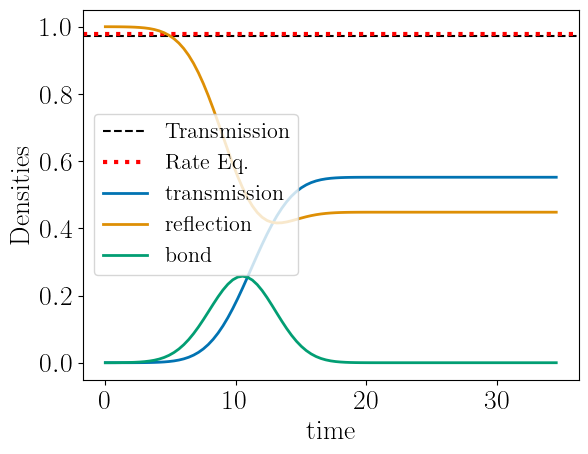

In [68]:
t_ = 0.01
Om = 0.6

k0_ = K0_unique[-1] 
cond_ = (full_data_df["t"]==t_)  & (full_data_df["K0"]==k0_) & (full_data_df["alfabond"]==af) & (full_data_df["Omega"]== Om )

curr_df = full_data_df[cond_].copy()
time_range = np.asarray(curr_df["times"].item())    
Δ = curr_df["Spread"].item() # initial spread of the wavepacket
Bindex = curr_df.bond_index.item()# position of the bond
# spread at time of measurement
Spread_B = (Δ/np.sqrt(2))*np.sqrt(1 + ( (Bindex - X0_)/(Δ*Δ*k0_))**2 )
# density matrix in time 
rhot = curr_df["qubit_rho"].item()

# notice hoow tis not the renormalized interaction strength
# baecause this is the stationary limit and NOT von neuman
V0 = Om*prob0
Tprob = get_transmision_proba(V0, k0_, Δ)

# from gurvitz/romito
Tinit = 1 # unocupeid proba

currexp = Tinit+prob0*(Tprob-Tinit)
print(currexp)

traj_matrix = curr_df["occupations"].item()
# occupation to the right of the bond at
occu_T = np.sum(traj_matrix[Bindex+2:, :], axis=0)
occu_R = np.sum(traj_matrix[:Bindex, :], axis=0)
occu_B = np.sum(traj_matrix[Bindex:Bindex+2, :], axis=0)
# from the numerics this is
plt.axhline(Tprob, color="black", linestyle="dashed", label="Transmission")
plt.axhline(currexp, color="red", linestyle="dotted", linewidth=3, label="Rate Eq.")
plt.plot(time_range,occu_T, label="transmission", linewidth=2)
plt.plot(time_range,occu_R, label="reflection", linewidth=2)
plt.plot(time_range, occu_B, label="bond", linewidth=2 )

plt.xlabel("time")
plt.ylabel("Densities")

plt.legend()

estimated freq (Hilbert):  0.06724724189151711
estimated freq (derivative):  0.010000000000000718
true freq:  0.01


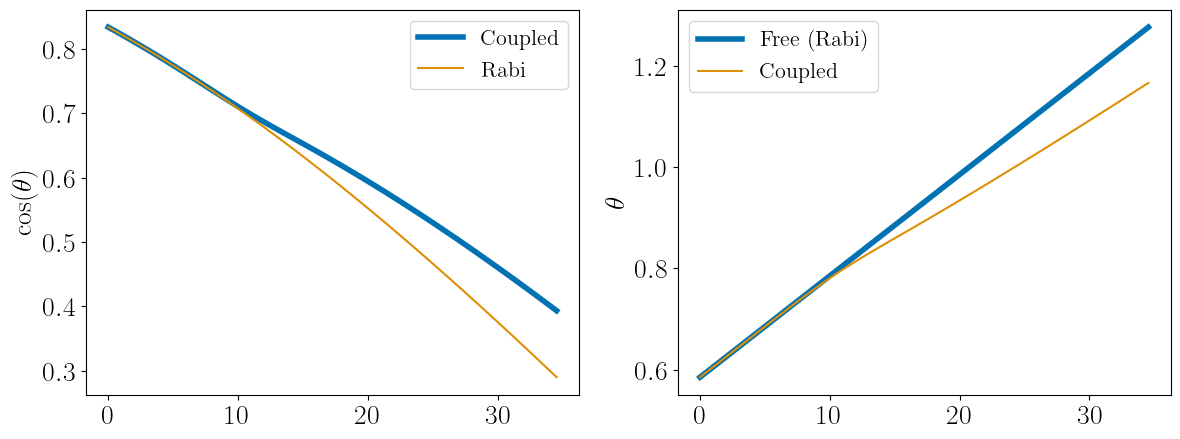

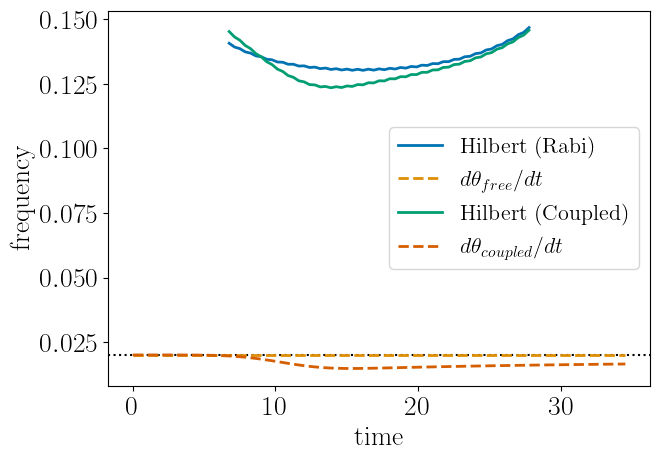

In [69]:
f,ax = plt.subplots(1,2, figsize=(2*bwidth, bheight))

# by double angle identity
coupled_osc = np.asarray(np.real(curr_df["cos_theta"].item()))
coupled_theta = np.arccos(coupled_osc)

# get THE FREE orbit in bloch sphere
rho_free_list, theta_free_list, phi_free_list = get_free_orbit(rhot[0], np.real(curr_df["cos_theta"].item())[0],0, time_range,t_)

rabi_osc = np.cos(theta_free_list)
ax[0].plot(time_range, coupled_osc, linewidth = 4, label="Coupled")
ax[0].plot(time_range, rabi_osc, label="Rabi")
ax[0].legend()

ax[1].plot(time_range, theta_free_list, linewidth = 4, label="Free (Rabi)")
ax[1].plot(time_range, coupled_theta, label="Coupled")
ax[0].set_ylabel(r"$\cos(\theta)$")
ax[1].set_ylabel(r"$\theta$")
ax[1].legend()

# Calculate derivative of theta to get frequency
dt = time_range[1] - time_range[0]
theta_free_deriv = np.abs(np.gradient(theta_free_list, dt))
coupled_theta_deriv = np.abs(np.gradient(coupled_theta, dt))

# estimating the change in frequency by two methods: Derivative of theta and hilbert
_, rabi_om = get_instant_freq(rabi_osc - np.mean(rabi_osc),times)
_, couple_om = get_instant_freq(coupled_osc - np.mean(coupled_osc),times)

# remove the artifacts from edge effects
rems = int(0.20*len(rabi_om))
rabi_om = rabi_om[rems:-rems]
couple_om = couple_om[rems:-rems]

fig, axes = plt.subplots(1, 1, figsize=(bwidth, bheight))

# Compare Hilbert vs derivative method
axes.axhline(2*t_, c="black", linestyle=':')

axes.plot(time_range[rems:-rems], rabi_om, lw=2, label="Hilbert (Rabi)")
axes.plot(time_range, theta_free_deriv, lw=2, ls='--', label=r"$d\theta_{free}/dt$")
axes.plot(time_range[rems:-rems], couple_om, lw=2, label="Hilbert (Coupled)")
axes.plot(time_range, coupled_theta_deriv, lw=2, ls='--', label=r"$d\theta_{coupled}/dt$")

axes.set_xlabel("time")
axes.set_ylabel("frequency")
axes.legend()

plt.tight_layout()

print("estimated freq (Hilbert): ", np.mean(rabi_om)/2)
print("estimated freq (derivative): ", np.mean(theta_free_deriv)/2)
print("true freq: ", t_)

plt.xlabel("time")
plt.ylabel("frequency")
plt.legend()

**Note:** For time-dependent frequencies (like the coupled system), the Hilbert transform method above is the correct approach. 

Alternatively, you can use sliding window fits to capture local frequency changes:

Text(0, 0.5, 'Purity')

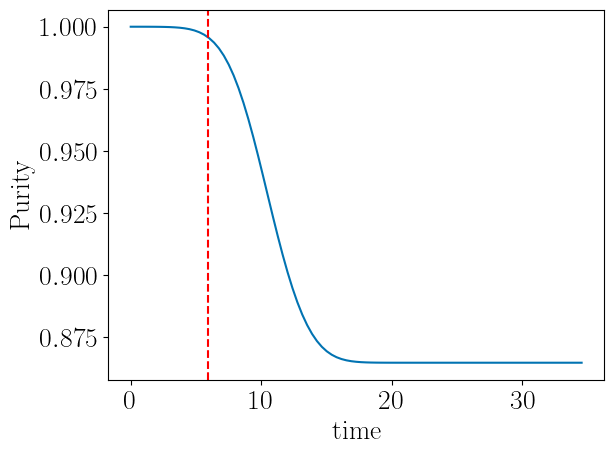

In [70]:
plt.plot(time_range,curr_df["purity"].item())
plt.axvline(curr_df["time_at_bond"].item(), color="red", linestyle="dashed", label="Time at bond")
plt.xlabel("time")
plt.ylabel("Purity")

# Backaction on the qubit

using our analytical boundaries

In [71]:
# filter out for the parameters we want 
back_df = data_df.sort_values(by="K0")
# Delta_phi_max backaction_max
B_df = back_df.pivot(index='K0', columns='t', values='Delta_phi_max')

# Create a pivot table for purity l
purity_pivot = back_df.pivot(index='K0', columns='t', values='purity_last')

boundary_points = back_df[back_df["purity_last"]<0.9932][["K0","t","purity_last","Delta_phi_max","backaction_max"]]


print(Om_)


0.05


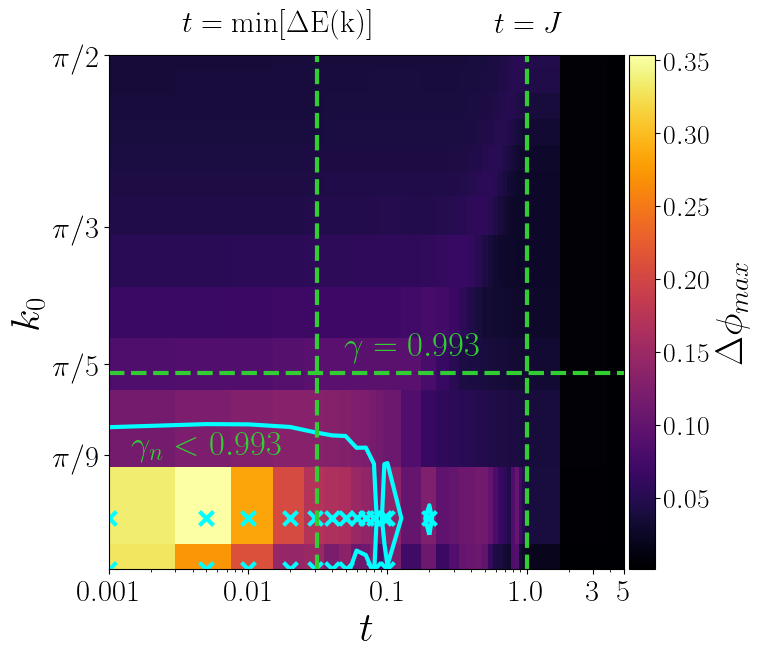

In [72]:
fig, ax = plt.subplots(1,1,figsize=(bwidth+1,bwidth))

vg_array = B_df.index
t_array = B_df.columns
#im = ax.contourf(t_array, vg_array, B_df.values,levels=8, cmap="inferno")
im = ax.pcolormesh(t_array, vg_array, B_df.values, cmap="inferno", shading='auto')

plt.contour(purity_pivot.columns, purity_pivot.index, purity_pivot.values, 
           levels=[0.993], colors='cyan', linewidths=3)

plt.scatter(boundary_points["t"], boundary_points["K0"], 
           color='cyan', s=100, marker='x', linewidth=3)
# lines from perturbation theory
ax.vlines([np.pi/(LL+1), J], ymin=0.0*np.pi/2, ymax=np.pi/2, color='limegreen', lw=3, linestyle="dashed", clip_on=False)  # tick-like line

# Purity according to von Neuman
n_ = 6 # this is the scaling
K0_ = 2*n_*Om_
R2 = np.exp(-(2*Om_/K0_)**2)
purity = 0.5*( 1+ R2*np.sin(af)**2 +np.cos(af)**2 )

ax.axhline(K0_, color='limegreen', lw=3, linestyle="dashed", clip_on=False)  # horizontal line at 2*Omega

# get axis scale and ticks
plt.xscale('log')
ax.set_xlim(0.001, 5)
ax.set_ylim(min(K0_unique), max(K0_unique))
ax.set_xticks( [0.001, 0.01,0.1,1.0,3, 5], [0.001, 0.01,0.1,1.0,3,5] ,fontsize=22)
ax.set_yticks( [np.pi/9,np.pi/5,np.pi/3,np.pi/2], labels=[r"$\pi/9$",r"$\pi/5$",r"$\pi/3$",r"$\pi/2$"],fontsize=22 )

# anotate a bit 
ax.annotate(r"$\gamma = {0:.3f}$".format(purity), xy=(0.15, K0_), 
            xytext=(0.15, K0_+0.05),ha='center', c="limegreen", fontsize= 25,fontweight='bold')

ax.annotate(r"$\gamma_n < {0:.3f}$".format(purity), xy=(0.001, np.pi/9), 
            xytext=(0.005, np.pi/9),ha='center', c="limegreen", fontsize= 25,fontweight='bold')

y_tick = np.pi/2
ax.annotate(
    r'$t=\rm{min}[ \Delta E(k)]$', 
    xy=(np.pi/(LL+1), y_tick), 
    xytext=(np.pi/(LL+1) - 0.015, y_tick + 0.07), fontsize=22,ha='center')
ax.annotate(
    r'$t=J$', 
    xy=(J, y_tick), 
    xytext=(J, y_tick + 0.07), fontsize=22,ha='center')
# set up color bar
divider = make_axes_locatable(ax)
cax = divider.append_axes('right', size='5%', pad=0.05)
cbar = fig.colorbar(im, cax, shrink=0.9)   
cbar.ax.set_ylabel(r'$\Delta \phi_{max}$', rotation=90, fontsize=28)

ax.set_ylabel(r"$k_0$",fontweight='bold',fontsize=30)
ax.set_xlabel(r"$t$",fontweight='bold',fontsize=30)

plt.tight_layout()

## Comparing $\Delta \phi$ and dephasing to von Neuman

Test Several interaction strength and $t$ to see where the whole thing breaks down. ALso remember the Legget-Garg paper where they create a phase gain

**Exponential decrease in purity for VN is consisten with dephasing, but notice how. there are ooints where this is not true anymore specifically, when we go up in the qubits dynamics at aroun t=0.1 for example, this suggest that there is a regime where we can minimizer the backaction even more by including some coherent quantum dynamics** Also because it appears in the off-diagonal elements.

In [73]:
Times_bond = back_df[back_df["t"]==0.0001]["time_at_bond"].unique()

Δ = back_df["Spread"].unique()[0] # initial spread of the wavepacket
Bindex = back_df.bond_index.unique()[0] # position of the bond
K0_cont = np.linspace(0.1*np.pi/2,np.pi/2,100)
vg_ = 2*J*K0_cont
TauB = (Bindex - X0_)/vg_ # Time to reach the bond in numerics/tight binding
# get the spread when we hit the bond
Spread_B = (Δ/np.sqrt(2))*np.sqrt(1 + ( (Bindex - X0_)/(Δ*Δ*K0_cont))**2 )

phase_gain = Om_*Spread_B/2


**Maybe the issue with the phases is the signe convention? or the fact that we plot the final phi instead of the phi difference**

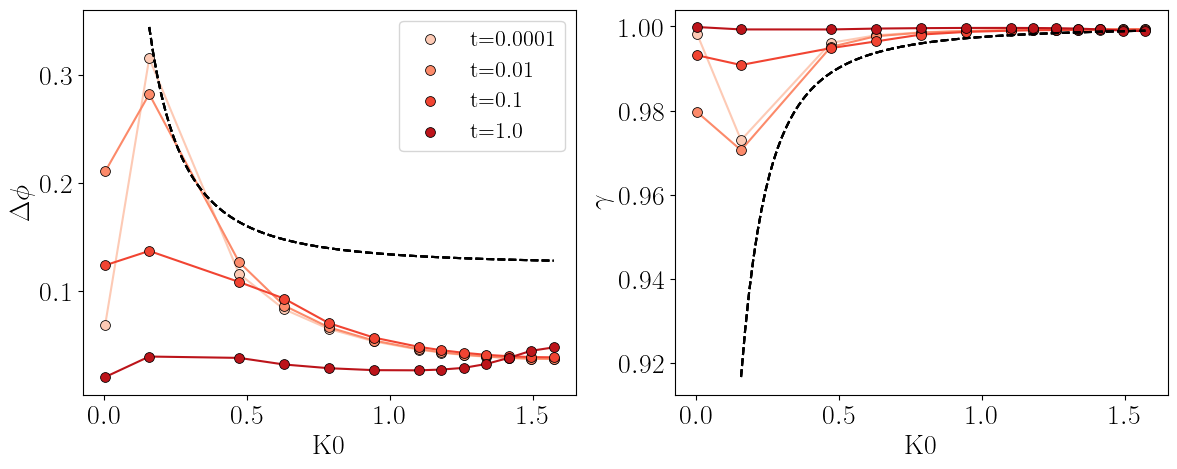

In [74]:
n_colors = 4
colors = [plt.cm.Reds(i/(n_colors+1)) for i in range(1, n_colors+1)]
# what we expect from von neuman
R2 = np.exp(-(2*Om_*J/K0_cont)**2)
Purity_theo = 0.5*(1+(np.sin(af)**2)* R2+ np.cos(af)**2)

fig, ax = plt.subplots(1,2,figsize=(2*bwidth,bheight))

tlist = [0.0001, 0.01, 0.1, 1.0]

for i in range(0,len(tlist)):
    ti = tlist[i]
    sns.lineplot(ax=ax[0], data= back_df[back_df["t"]==ti], x="K0", y="Delta_phi_max", color=colors[i], zorder=0)
    sns.scatterplot(ax=ax[0], data= back_df[back_df["t"]==ti], x="K0", y="Delta_phi_max", label="t={}".format(ti), s=50, edgecolor="black",  color=colors[i])
    ax[0].plot(K0_cont, phase_gain, linestyle="dashed",c="black")

    sns.lineplot(ax=ax[1], data= back_df[back_df["t"]==ti], x="K0", y="purity_last", color=colors[i], zorder=0)
    sns.scatterplot(ax=ax[1], data= back_df[back_df["t"]==ti], x="K0", y="purity_last",color=colors[i], edgecolor="black", s=50)
    ax[1].plot(K0_cont, Purity_theo, linestyle="dashed",c="black")

ax[0].set_ylabel(r"$\Delta \phi$")
ax[1].set_ylabel(r"$\gamma$")

plt.savefig(fig_route+"Delta_phi_and_purity_vs_K0.png", bbox_inches="tight")

## Zeno Effect

Gurvitz does mention zeno effect.

Here we can show how much does the qpc affect the qubit by estimating the change in theta. Regarding the zeno effect, the qubit's dynamics become quite important here

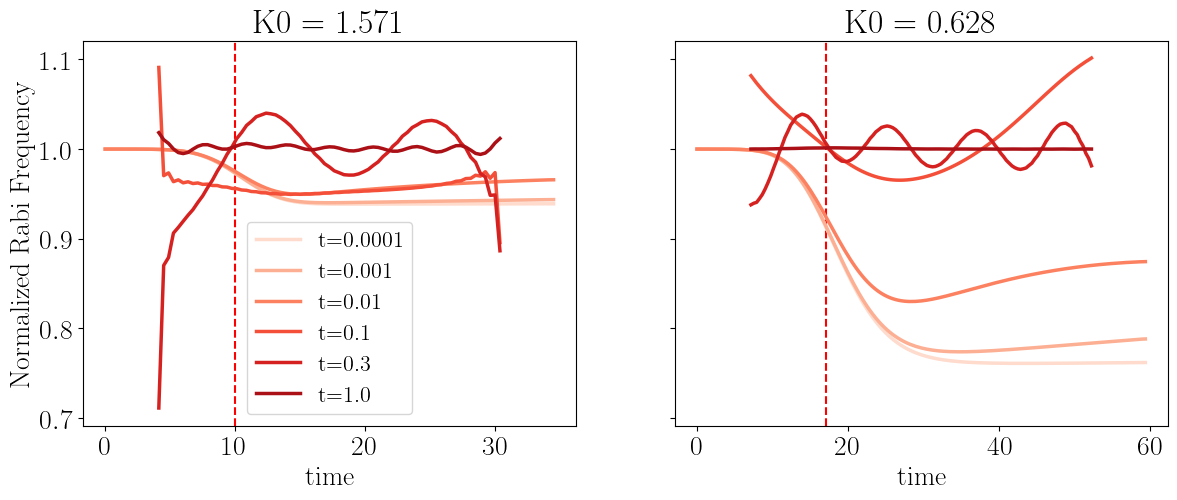

In [75]:
Om = 0.3
K0 = K0_unique[-1] 
K02 = K0_unique[3]

# plot the time evolution of the frequencies for several t's
t_choice = [0.0001, 0.001, 0.01,0.1, 0.3, 1.0]
colorb_list = sns.color_palette("Reds", len(t_choice))

f,ax = plt.subplots(1,2, figsize=(2*bwidth, bheight), sharey=True)

# plot the time at bond from numerics
ax[0].axvline(-(X0_ - Bindex)/(2*J*np.sin(K0)), c="red", linestyle='--')
ax[1].axvline(-(X0_ - Bindex)/(2*J*np.sin(K02)), c="red", linestyle='--')

for i in range(0, len(t_choice)):
    t_ = t_choice[i]
    cond_ = (full_data_df["alfabond"]==af) & (full_data_df["Omega"]== Om ) & (full_data_df["K0"]==K0) & (full_data_df["t"]==t_)
    cond2_ = (full_data_df["alfabond"]==af) & (full_data_df["Omega"]== Om ) & (full_data_df["K0"]==K02 ) & (full_data_df["t"]==t_)
    curr_df = full_data_df[cond_].copy()
    curr_df2 = full_data_df[cond2_].copy()
    time_range = np.asarray(curr_df["times"].item())
    time_range2 = np.asarray(curr_df2["times"].item())

    # from the numerics this is
    #ax[0].axhline(t_, c="black", linestyle=':')
    #ax[1].axhline(t_, c="black", linestyle=':')

    if(t_<0.1):
        ax[0].plot(time_range, curr_df["couple_freq_deriv"].item()/(2*t_), lw=2.5, label="t={}".format(t_), color=colorb_list[i])
        ax[1].plot(time_range2, curr_df2["couple_freq_deriv"].item()/(t_*2), lw=2.5, label="t={}".format(t_), color=colorb_list[i])
        
    else:
        ax[0].plot(curr_df["hilbert_time_range"].item(), curr_df["couple_freq_hilbert"].item()/(2*t_), lw=2.5, label="t={}".format(t_), color=colorb_list[i])
        ax[1].plot(curr_df2["hilbert_time_range"].item(), curr_df2["couple_freq_hilbert"].item()/(t_*2), lw=2.5, label="t={}".format(t_), color=colorb_list[i])

ax[0].set_title("K0 = {:.3f}".format(K0))
ax[1].set_title("K0 = {:.3f}".format(K02))
# ax[0].set_yscale("log")
ax[0].set_ylabel("Normalized Rabi Frequency")
ax[0].set_xlabel("time")
# ax[0].set_ylim(0.5,1.1)
ax[1].set_xlabel("time")
ax[0].legend()


Its probably better to plot the relative change in theta to normalize stuff properly

Probing how the oscillations change when increasing $\Omega$ for slow, meidum, fast qubit.

Notice how the Rabi oscillations don't fully die out, remember that a fuly statistical mixture of purity =1/2 is only possible when the qubit is in the middle of both 0 and 1. SO it makes sense that increasing the Rabi a bit 
will make it pass through that point more thus reducing the purity more. What I don't understand is that there is a revival of the purity at high Omegas. I dont get how. But what is clear is that the oscillation amplitude is reduced always

**These weird oscllations may be related to Figure.2 in Korotkov's Continuous quantum measurement of a double dot**

1.5707963267948966 5.0
[ 0.05  0.1   0.3   0.6   1.    2.    3.    5.   10.  ]


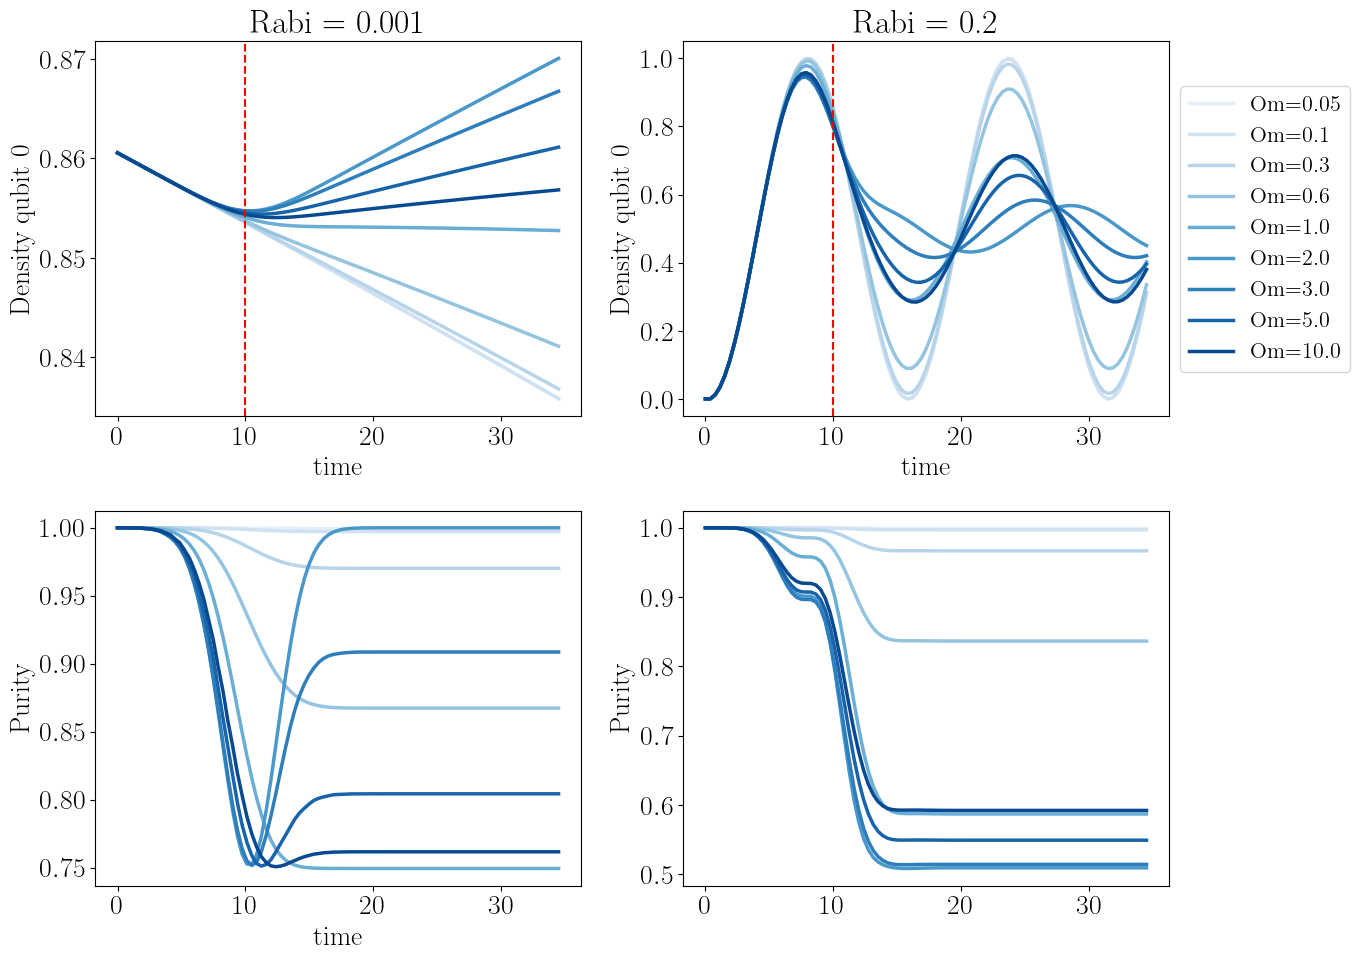

In [76]:
K0 = K0_unique[-1]
print(K0,rabi)
omega_list = np.sort(full_data_df[full_data_df["Omega"]<11]["Omega"].unique())
print(omega_list)
colorb_list = sns.color_palette("Blues", len(omega_list))

fig, ax = plt.subplots(2,2,figsize=(2*bwidth,2*bheight))
for i in range(0, len(omega_list)):
    Om = omega_list[i]
    # plot first rabi case
    rabi1 = 0.001
    cond_ = (full_data_df["alfabond"]==af) & (full_data_df["Omega"]== Om ) & (full_data_df["K0"]==K0 ) & (full_data_df["t"]==rabi1)
    curr_df = full_data_df[cond_].copy()
    time_range = np.asarray(curr_df["times"].item())
    ax[0,0].plot(time_range, curr_df["d0_density"].item(), lw=2.5, label="Om={}".format(Om), color=colorb_list[i])
    ax[1,0].plot(time_range, curr_df["purity"].item(), lw=2.5,color=colorb_list[i])

    # plot second rabi case
    rabi2 = 0.2
    cond_ = (full_data_df["alfabond"]==af) & (full_data_df["Omega"]== Om ) & (full_data_df["K0"]==K0 ) & (full_data_df["t"]==rabi2)
    curr_df = full_data_df[cond_].copy()
    time_range = np.asarray(curr_df["times"].item())
    ax[0,1].plot(time_range, curr_df["d0_density"].item(), lw=2.5, label="Om={}".format(Om), color=colorb_list[i])
    ax[1,1].plot(time_range, curr_df["purity"].item(), lw=2.5,color=colorb_list[i])

time_at_bond = (Bindex - X0_)/(2*J*np.sin(K0))
ax[0,0].axvline(time_at_bond, c="red", linestyle='--', label="Time at bond")
ax[0,0].set_xlabel("time")
ax[0,0].set_ylabel("Density qubit 0")
# ax[0,0].set_ylim(0.8,0.9)
ax[0,0].set_title("Rabi = {}".format(rabi1))
ax[1,0].set_xlabel("time")
ax[1,0].set_ylabel("Purity")

ax[0,1].legend(loc='center left', bbox_to_anchor=(1, 0.5))
ax[0,1].axvline(time_at_bond, c="red", linestyle='--', label="Time at bond")
ax[0,1].set_xlabel("time")
ax[0,1].set_ylabel("Density qubit 0")
# ax[0,1].set_ylim(-0.03,1.03)
ax[1,1].set_ylabel("Purity")
ax[0,1].set_title("Rabi = {}".format(rabi2))

plt.tight_layout()



# Entanglement and Info gain

How much more do we gain by looking at the information gain near the t=0.1 regime? because here we reduce the backaction.

In [84]:
# filter out for the parameters we want 
cond_ = (data_df["Omega"]==0.05)  & (data_df["qubit_init"]=="fixed") & (data_df["X0"]==X0_) & (data_df["alfabond"]==af)

data_S = data_df[cond_].sort_values(by="K0")
# FOR NOW
# data_S = data_S.drop_duplicates(subset=["K0", "t"], keep="first")
S_df = data_S.pivot(index='K0', columns='t', values='Max_entropy')


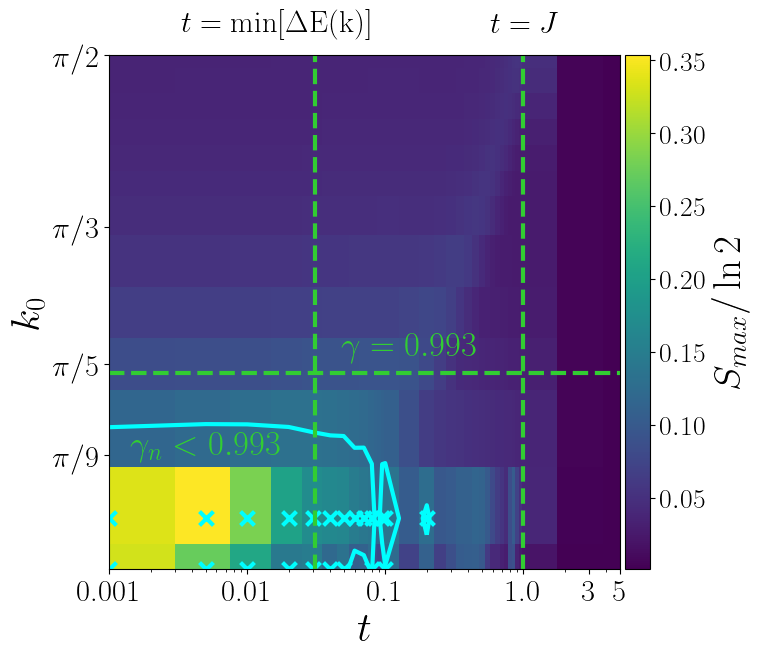

In [86]:
fig, ax = plt.subplots(1,1,figsize=(bwidth+1,bwidth))

vg_array = S_df.index
t_array = S_df.columns
#im = ax.contourf(t_array, vg_array, S_df.values,levels=8, cmap="viridis")
im = ax.pcolormesh(t_array, vg_array, B_df.values, cmap="viridis", shading='auto')

plt.contour(purity_pivot.columns, purity_pivot.index, purity_pivot.values, 
           levels=[0.993], colors='cyan', linewidths=3)

plt.scatter(boundary_points["t"], boundary_points["K0"], 
           color='cyan', s=100, marker='x', linewidth=3)
# lines from perturbation theory
ax.vlines([np.pi/(LL+1), J], ymin=0.0*np.pi/2, ymax=np.pi/2, color='limegreen', lw=3, linestyle="dashed", clip_on=False)  

# Purity according to von Neuman
n_ = 6 # this is the scaling
K0_ = 2*n_*Om_
R2 = np.exp(-(2*Om_/K0_)**2)
purity = 0.5*( 1+ R2*np.sin(af)**2 +np.cos(af)**2 )

ax.axhline(K0_, color='limegreen', lw=3, linestyle="dashed", clip_on=False)  # horizontal line at 2*Omega

# get axis scale and ticks
plt.xscale('log')
ax.set_xlim(0.001, 5)
ax.set_ylim(min(K0_unique), max(K0_unique))
ax.set_xticks( [0.001, 0.01,0.1,1.0,3, 5], [0.001, 0.01,0.1,1.0,3,5] ,fontsize=22)
ax.set_yticks( [np.pi/9,np.pi/5,np.pi/3,np.pi/2], labels=[r"$\pi/9$",r"$\pi/5$",r"$\pi/3$",r"$\pi/2$"],fontsize=22 )

# anotate a bit 
ax.annotate(r"$\gamma = {0:.3f}$".format(purity), xy=(0.15, K0_), 
            xytext=(0.15, K0_+0.05),ha='center', c="limegreen", fontsize= 25,fontweight='bold')

ax.annotate(r"$\gamma_n < {0:.3f}$".format(purity), xy=(0.001, np.pi/9), 
            xytext=(0.005, np.pi/9),ha='center', c="limegreen", fontsize= 25,fontweight='bold')

y_tick = np.pi/2
ax.annotate(
    r'$t=\rm{min}[ \Delta E(k)]$', 
    xy=(np.pi/(LL+1), y_tick), 
    xytext=(np.pi/(LL+1) - 0.015, y_tick + 0.07), fontsize=22,ha='center')
ax.annotate(
    r'$t=J$', 
    xy=(J, y_tick), 
    xytext=(J, y_tick + 0.07), fontsize=22,ha='center')
# set up color bar
divider = make_axes_locatable(ax)
cax = divider.append_axes('right', size='5%', pad=0.05)
cbar = fig.colorbar(im, cax, shrink=0.9)   
cbar.ax.set_ylabel(r'$S_{max}/\ln{2}$', rotation=90, fontsize=28)

ax.set_ylabel(r"$k_0$",fontweight='bold',fontsize=30)
ax.set_xlabel(r"$t$",fontweight='bold',fontsize=30)

plt.tight_layout()

plt.savefig(fig_route+"entropy_vs_K0_and_t.png", bbox_inches="tight")

# What about a fully delocalized qubit at measurement?

In [79]:
print(full_data_df["alfabond"].sort_values().unique())
alfa = full_data_df["alfabond"].sort_values().unique()[-1]
print(np.cos(alfa/2)**2)

[0.         0.31415927 0.78539816 1.57079633]
0.5000000000000001


1.5707963267948966 5.0
[ 0.05  0.1   0.3   0.6   1.    2.    3.    5.   10.  ]


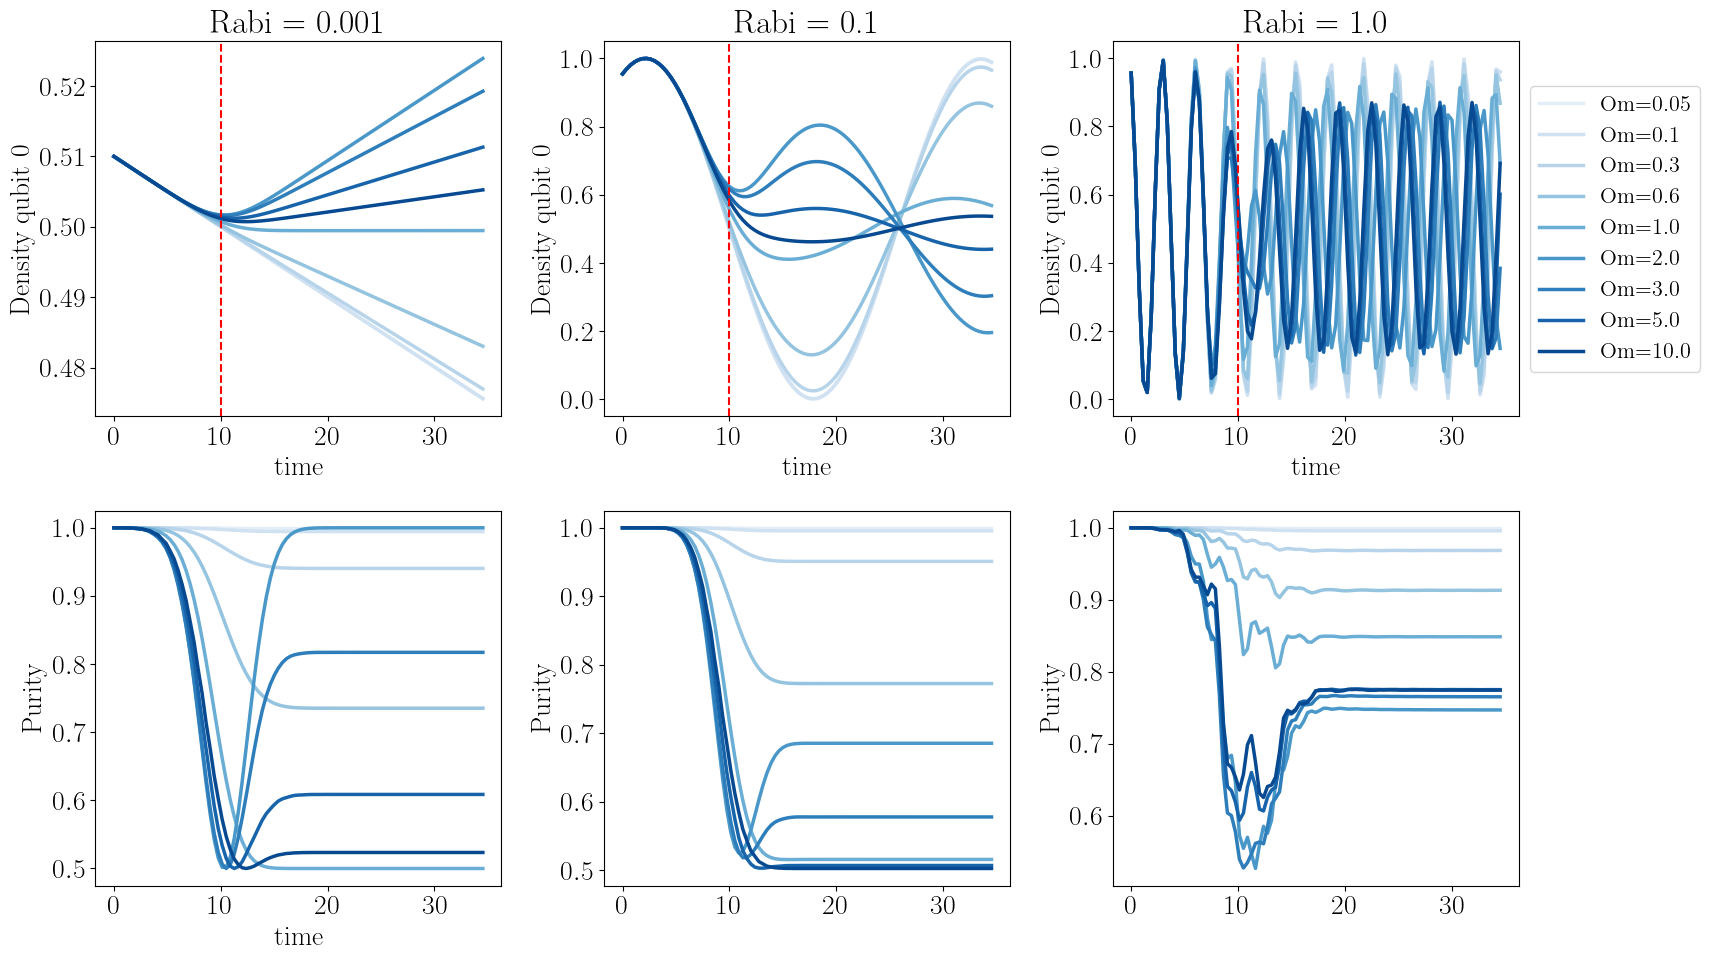

In [80]:
K0 = K0_unique[-1]
print(K0,rabi)
omega_list = np.sort(full_data_df[full_data_df["Omega"]<11]["Omega"].unique())
print(omega_list)
colorb_list = sns.color_palette("Blues", len(omega_list))

fig, ax = plt.subplots(2,3,figsize=(2.5*bwidth,2*bheight))
for i in range(0, len(omega_list)):
    Om = omega_list[i]
    # plot first rabi case
    rabi1 = 0.001
    cond_ = (full_data_df["alfabond"]==alfa) & (full_data_df["Omega"]== Om ) & (full_data_df["K0"]==K0 ) & (full_data_df["t"]==rabi1)
    curr_df = full_data_df[cond_].copy()
    time_range = np.asarray(curr_df["times"].item())
    ax[0,0].plot(time_range, curr_df["d0_density"].item(), lw=2.5, label="Om={}".format(Om), color=colorb_list[i])
    ax[1,0].plot(time_range, curr_df["purity"].item(), lw=2.5,color=colorb_list[i])

    # plot second rabi case
    rabi2 = 0.1
    cond_ = (full_data_df["alfabond"]==alfa) & (full_data_df["Omega"]== Om ) & (full_data_df["K0"]==K0 ) & (full_data_df["t"]==rabi2)
    curr_df = full_data_df[cond_].copy()
    time_range = np.asarray(curr_df["times"].item())
    ax[0,1].plot(time_range, curr_df["d0_density"].item(), lw=2.5, label="Om={}".format(Om), color=colorb_list[i])
    ax[1,1].plot(time_range, curr_df["purity"].item(), lw=2.5,color=colorb_list[i])

    # plot third rabi case
    rabi3 = 1.0
    cond_ = (full_data_df["alfabond"]==alfa) & (full_data_df["Omega"]== Om ) & (full_data_df["K0"]==K0 ) & (full_data_df["t"]==rabi3)
    curr_df = full_data_df[cond_].copy()
    time_range = np.asarray(curr_df["times"].item())
    ax[0,2].plot(time_range, curr_df["d0_density"].item(), lw=2.5, label="Om={}".format(Om), color=colorb_list[i])
    ax[1,2].plot(time_range, curr_df["purity"].item(), lw=2.5,color=colorb_list[i])

time_at_bond = (Bindex - X0_)/(2*J*np.sin(K0))
ax[0,0].axvline(time_at_bond, c="red", linestyle='--', label="Time at bond")
ax[0,0].set_xlabel("time")
ax[0,0].set_ylabel("Density qubit 0")
# ax[0,0].set_ylim(0.8,0.9)
ax[0,0].set_title("Rabi = {}".format(rabi1))
ax[1,0].set_xlabel("time")
ax[1,0].set_ylabel("Purity")

ax[0,1].axvline(time_at_bond, c="red", linestyle='--', label="Time at bond")
ax[0,1].set_xlabel("time")
ax[0,1].set_ylabel("Density qubit 0")
# ax[0,1].set_ylim(-0.03,1.03)
ax[1,1].set_ylabel("Purity")
ax[0,1].set_title("Rabi = {}".format(rabi2))

ax[0,2].legend(loc='center left', bbox_to_anchor=(1, 0.5))
ax[0,2].axvline(time_at_bond, c="red", linestyle='--', label="Time at bond")
ax[0,2].set_xlabel("time")
ax[0,2].set_ylabel("Density qubit 0")
# ax[0,1].set_ylim(-0.03,1.03)
ax[1,2].set_ylabel("Purity")
ax[0,2].set_title("Rabi = {}".format(rabi3))

plt.tight_layout()

plt.savefig(fig_route+"density_and_purity_time_evolution.png", bbox_inches="tight")

In [81]:
# filter out for the parameters we want 
cond_ = (full_data_df["Omega"]==0.05)  & (full_data_df["qubit_init"]=="fixed") & (full_data_df["X0"]==X0_) & (full_data_df["alfabond"]==alfa)

data_S = full_data_df[cond_].sort_values(by="K0")
# FOR NOW
# data_S = data_S.drop_duplicates(subset=["K0", "t"], keep="first")
S_df = data_S.pivot(index='K0', columns='t', values='Max_entropy')

S_df

t,0.0001,0.0005,0.0010,0.0050,0.0100,0.0200,0.0300,0.0400,0.0500,0.0600,...,0.6500,0.7000,0.7500,0.8000,0.8500,0.9000,0.9500,1.0000,2.5000,5.0000
K0,,,,,,,,,,,,,,,,,,,,,
1.178097,0.009294,0.009294,0.009294,0.009289,0.009271,0.009200,0.009082,0.008922,0.008727,0.008504,...,0.006385,0.004962,0.003776,0.003060,0.002621,0.002428,0.002446,NaN,NaN,NaN
1.256637,0.008812,0.008812,0.008812,0.008808,0.008792,0.008729,0.008625,0.008484,0.008310,0.008109,...,0.007707,0.006604,0.005367,0.004245,0.003407,0.002927,0.002748,0.002771,0.000089,0.000020
1.335177,0.008461,0.008461,0.008461,0.008457,0.008443,0.008386,0.008292,0.008163,0.008004,0.007819,...,0.007640,0.007614,0.006955,0.005835,0.004823,0.004053,0.003574,0.003413,0.000087,0.000021
1.413717,0.008222,0.008222,0.008222,0.008218,0.008205,0.008152,0.008064,0.007944,0.007794,0.007620,...,0.006719,0.007258,0.007540,0.007325,0.006621,0.005744,0.005047,0.004569,0.000085,0.000022
1.492257,0.008083,0.008083,0.008083,0.008080,0.008067,0.008016,0.007932,0.007816,0.007672,0.007503,...,0.005994,0.006512,0.007123,0.007684,0.007963,0.007784,0.007125,0.006086,0.000085,0.000022
1.570796,0.008038,0.008038,0.008038,0.008034,0.008022,0.007972,0.007888,0.007774,0.007631,0.007465,...,0.005753,0.006205,0.006831,0.007598,0.008337,0.008697,0.008250,0.006874,0.000084,0.000022


TypeError: Dimensions of C (13, 36) should be one smaller than X(36) and Y(6) while using shading='flat' see help(pcolormesh)

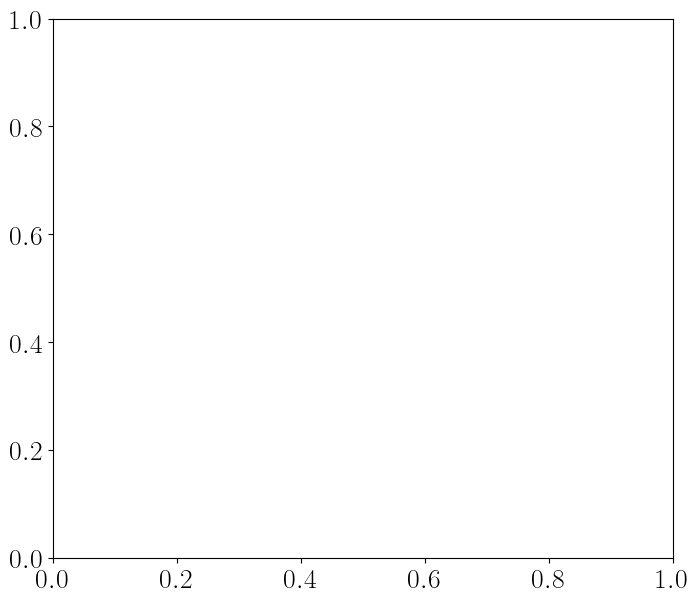

In [82]:
fig, ax = plt.subplots(1,1,figsize=(bwidth+1,bwidth))

vg_array = S_df.index
t_array = S_df.columns
#im = ax.contourf(t_array, vg_array, S_df.values,levels=8, cmap="viridis")
im = ax.pcolormesh(t_array, vg_array, B_df.values, cmap="viridis", shading='auto')

plt.contour(purity_pivot.columns, purity_pivot.index, purity_pivot.values, 
           levels=[0.993], colors='cyan', linewidths=3)

plt.scatter(boundary_points["t"], boundary_points["K0"], 
           color='cyan', s=100, marker='x', linewidth=3)
# lines from perturbation theory
ax.vlines([np.pi/(LL+1), J], ymin=0.0*np.pi/2, ymax=np.pi/2, color='limegreen', lw=3, linestyle="dashed", clip_on=False)  # tick-like line

# Purity according to von Neuman
n_ = 6 # this is the scaling
K0_ = 2*n_*Om_
R2 = np.exp(-(2*Om_/K0_)**2)
purity = 0.5*( 1+ R2*np.sin(af)**2 +np.cos(af)**2 )

ax.axhline(K0_, color='limegreen', lw=3, linestyle="dashed", clip_on=False)  # horizontal line at 2*Omega

# get axis scale and ticks
plt.xscale('log')
ax.set_xlim(0.001, 5)
ax.set_ylim(min(K0_unique), max(K0_unique))
ax.set_xticks( [0.001, 0.01,0.1,1.0,3, 5], [0.001, 0.01,0.1,1.0,3,5] ,fontsize=22)
ax.set_yticks( [np.pi/9,np.pi/5,np.pi/3,np.pi/2], labels=[r"$\pi/9$",r"$\pi/5$",r"$\pi/3$",r"$\pi/2$"],fontsize=22 )

# anotate a bit 
ax.annotate(r"$\gamma = {0:.3f}$".format(purity), xy=(0.15, K0_), 
            xytext=(0.15, K0_+0.05),ha='center', c="limegreen", fontsize= 25,fontweight='bold')

ax.annotate(r"$\gamma_n < {0:.3f}$".format(purity), xy=(0.001, np.pi/9), 
            xytext=(0.005, np.pi/9),ha='center', c="limegreen", fontsize= 25,fontweight='bold')

y_tick = np.pi/2
ax.annotate(
    r'$t=\rm{min}[ \Delta E(k)]$', 
    xy=(np.pi/(LL+1), y_tick), 
    xytext=(np.pi/(LL+1) - 0.015, y_tick + 0.07), fontsize=22,ha='center')
ax.annotate(
    r'$t=J$', 
    xy=(J, y_tick), 
    xytext=(J, y_tick + 0.07), fontsize=22,ha='center')
# set up color bar
divider = make_axes_locatable(ax)
cax = divider.append_axes('right', size='5%', pad=0.05)
cbar = fig.colorbar(im, cax, shrink=0.9)   
cbar.ax.set_ylabel(r'$S_{max}/\ln{2}$', rotation=90, fontsize=28)

ax.set_ylabel(r"$k_0$",fontweight='bold',fontsize=30)
ax.set_xlabel(r"$t$",fontweight='bold',fontsize=30)

plt.tight_layout()